In [1]:
import sqlite3

In [3]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS sales")
cursor.execute("""
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL,
        sale_date TEXT NOT NULL
    )
""")

sample_data = [
    ("Notebook", 10, 2.50, "2026-06-01"),
    ("Pen", 25, 0.75, "2026-06-01"),
    ("Notebook", 5, 2.50, "2026-06-02"),
    ("Backpack", 3, 18.00, "2026-06-02"),
    ("Pen", 15, 0.75, "2026-06-03"),
    ("Water Bottle", 8, 6.00, "2026-06-03"),
    ("Backpack", 2, 18.00, "2026-06-04"),
    ("Notebook", 12, 2.50, "2026-06-04"),
    ("Water Bottle", 10, 6.00, "2026-06-05"),
    ("Pen", 30, 0.75, "2026-06-05"),
    ("Backpack", 4, 18.00, "2026-06-06"),
    ("Water Bottle", 6, 6.00, "2026-06-06"),
]

cursor.executemany(
    "INSERT INTO sales (product, quantity, price, sale_date) VALUES (?, ?, ?, ?)",
    sample_data
)

conn.commit()
print("sales_data.db created with", len(sample_data), "records.")

sales_data.db created with 12 records.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

        product  total_qty  revenue
0      Backpack          9    162.0
1  Water Bottle         24    144.0
2      Notebook         27     67.5
3           Pen         70     52.5


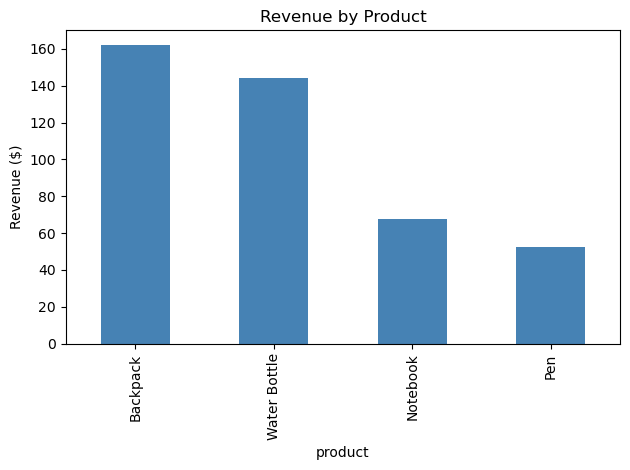

In [7]:
query = """
    SELECT product, SUM(quantity) AS total_qty, SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
    ORDER BY revenue DESC
"""
df = pd.read_sql_query(query, conn)
print(df)

df.plot(kind='bar', x='product', y='revenue', legend=False, color='steelblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()